# **Project Name**    -   Tourism Experience Analytics: Classification, Prediction, and Recommendation System



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual


# **Project Summary -**

This project focuses on analyzing and predicting tourism-related patterns using Machine Learning and Data Analytics techniques. The main objective of the project was to understand tourist behavior, attraction popularity, and user preferences to build an accurate tourism prediction and recommendation system.

The project began with data collection and preprocessing. Multiple datasets related to users, attractions, cities, countries, and tourism transactions were merged into a single dataframe for analysis. Data cleaning techniques were applied to handle missing values, remove duplicates, and treat outliers. Categorical variables were encoded into numerical form, and feature scaling techniques were used to prepare the data for machine learning models.

Exploratory Data Analysis (EDA) was performed using various visualizations such as count plots, bar charts, heatmaps, pair plots, and box plots. These visualizations helped identify important insights related to seasonal tourism trends, popular attraction types, tourist visit patterns, and rating distributions. Correlation analysis was also conducted to understand relationships among variables.

Feature engineering and feature selection techniques were used to improve model performance and reduce overfitting. Important features such as AttractionPopularity, AvgUserRating, VisitMonth, UserVisitCount, and AttractionTypeId were identified as major factors influencing tourist ratings and travel behavior.

**Several machine learning models were implemented, including:**

* Linear Regression
* Decision Tree Regressor
* Random Forest Regressor

Hyperparameter optimization using GridSearchCV was applied to improve model performance. The models were evaluated using regression metrics such as MAE, MSE, RMSE, and R² Score. Among all models, the optimized Random Forest Regressor achieved the best performance with the highest prediction accuracy and lowest error values.

The project also included a classification model for Visit Mode prediction and a recommendation system using collaborative filtering techniques to recommend attractions to users based on similarity analysis.

To improve model interpretability, feature importance analysis was performed using the Random Forest model. This helped identify the most influential features affecting prediction outcomes and provided valuable business insights for tourism planning and recommendation systems.

Finally, the best-performing model was saved using Joblib/Pickle format for deployment. A Streamlit web application was developed to allow users to input tourism-related data and receive prediction results interactively.

Overall, this project successfully demonstrated how Machine Learning can be used in tourism analytics to improve prediction accuracy, enhance customer recommendations, support business decision-making, and provide better tourism experiences.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Tourism agencies and travel platforms aim to enhance user experiences by leveraging data to provide personalized recommendations, predict user satisfaction, and classify potential user behavior. This project involves analyzing user preferences, travel patterns, and attraction features to achieve three primary objectives: regression, classification, and recommendation.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
!pip install streamlit

# Import Libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report
)

# Recommendation
from sklearn.metrics.pairwise import cosine_similarity

# Streamlit
import streamlit as st

### Dataset Loading

In [3]:
# Load Dataset

transactions = pd.read_excel("Transaction.xlsx")
users = pd.read_excel("User.xlsx")
cities = pd.read_excel("City.xlsx")
types = pd.read_excel("Type.xlsx")
visit_modes = pd.read_excel("Mode.xlsx")
countries = pd.read_excel("Country.xlsx")
regions = pd.read_excel("Region.xlsx")
continents = pd.read_excel("Continent.xlsx")
items = pd.read_excel("Item.xlsx")

### Dataset First View

In [4]:
# Dataset First Look

transactions.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


In [5]:
cities.head()


,CityId,CityName,CountryId
0,0,-,0
1,1,Douala,1
2,2,South Region,1
3,3,N'Djamena,2
4,4,Kigali,3


In [6]:
continents.head()


,ContinentId,Continent
0,0,-
1,1,Africa
2,2,America
3,3,Asia
4,4,Australia & Oceania


In [7]:
countries.head()


,CountryId,Country,RegionId
0,0,-,0
1,1,Cameroon,1
2,2,Chad,1
3,3,Rwanda,1
4,4,Ethiopia,2


In [8]:
items.head()


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak


In [9]:
visit_modes.head()


,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends


In [10]:
regions.head()


,Region,RegionId,ContinentId
0,-,0,0
1,Central Africa,1,1
2,East Africa,2,1
3,North Africa,3,1
4,Southern Africa,4,1


In [11]:
types.head()


,AttractionTypeId,AttractionType
0,2,Ancient Ruins
1,10,Ballets
2,13,Beaches
3,19,Caverns & Caves
4,34,Flea & Street Markets


In [12]:
users.head()

,UserId,ContinentId,RegionId,CountryId,CityId
0,14,5,20,155,220.0
1,16,3,14,101,3098.0
2,20,4,15,109,4303.0
3,23,1,4,22,154.0
4,25,3,14,101,3098.0


### Dataset Rows & Columns count

In [13]:
# Dataset Rows & Columns count
cities.shape

(9143, 3)

In [14]:
continents.shape

(6, 2)

In [15]:
countries.shape

(165, 3)

In [16]:
items.shape

(30, 5)

In [17]:
visit_modes.shape

(6, 2)

In [18]:
regions.shape

(22, 3)

In [19]:
transactions.shape

(52930, 7)

In [20]:
types.shape

(17, 2)

In [21]:
users.shape

(33530, 5)

### Dataset Information

In [22]:
# Dataset Info

cities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9143 entries, 0 to 9142
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CityId     9143 non-null   int64 
 1   CityName   9142 non-null   object
 2   CountryId  9143 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 214.4+ KB


In [23]:
continents.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ContinentId  6 non-null      int64 
 1   Continent    6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [24]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CountryId  165 non-null    int64 
 1   Country    165 non-null    object
 2   RegionId   165 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 4.0+ KB


In [25]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   AttractionId       30 non-null     int64 
 1   AttractionCityId   30 non-null     int64 
 2   AttractionTypeId   30 non-null     int64 
 3   Attraction         30 non-null     object
 4   AttractionAddress  30 non-null     object
dtypes: int64(3), object(2)
memory usage: 1.3+ KB


In [26]:
visit_modes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   VisitModeId  6 non-null      int64 
 1   VisitMode    6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [27]:
regions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Region       22 non-null     object
 1   RegionId     22 non-null     int64 
 2   ContinentId  22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


In [28]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TransactionId  52930 non-null  int64
 1   UserId         52930 non-null  int64
 2   VisitYear      52930 non-null  int64
 3   VisitMonth     52930 non-null  int64
 4   VisitMode      52930 non-null  int64
 5   AttractionId   52930 non-null  int64
 6   Rating         52930 non-null  int64
dtypes: int64(7)
memory usage: 2.8 MB


In [29]:
types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   AttractionTypeId  17 non-null     int64 
 1   AttractionType    17 non-null     object
dtypes: int64(1), object(1)
memory usage: 404.0+ bytes


In [30]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33530 entries, 0 to 33529
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   UserId       33530 non-null  int64  
 1   ContinentId  33530 non-null  int64  
 2   RegionId     33530 non-null  int64  
 3   CountryId    33530 non-null  int64  
 4   CityId       33526 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 1.3 MB


#### Duplicate Values

In [31]:
# Dataset Duplicate Value Count
cities.duplicated().sum()

np.int64(0)

In [32]:
continents.duplicated().sum()

np.int64(0)

In [33]:
countries.duplicated().sum()

np.int64(0)

In [34]:
items.duplicated().sum()

np.int64(0)

In [35]:
visit_modes.duplicated().sum()

np.int64(0)

In [36]:
regions.duplicated().sum()

np.int64(0)

In [37]:
transactions.duplicated().sum()

np.int64(0)

In [38]:
types.duplicated().sum()

np.int64(0)

In [39]:
users.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [40]:
# Missing Values/Null Values Count
cities.isnull().sum()

,0
CityId,0
CityName,1
CountryId,0


In [41]:
continents.isnull().sum()

,0
ContinentId,0
Continent,0


In [42]:
countries.isnull().sum()

,0
CountryId,0
Country,0
RegionId,0


In [43]:
items.isnull().sum()

,0
AttractionId,0
AttractionCityId,0
AttractionTypeId,0
Attraction,0
AttractionAddress,0


In [44]:
visit_modes.isnull().sum()

,0
VisitModeId,0
VisitMode,0


In [45]:
regions.isnull().sum()

,0
Region,0
RegionId,0
ContinentId,0


In [46]:
regions.isnull().sum()

,0
Region,0
RegionId,0
ContinentId,0


In [47]:
transactions.isnull().sum()

,0
TransactionId,0
UserId,0
VisitYear,0
VisitMonth,0
VisitMode,0
AttractionId,0
Rating,0


In [48]:
types.isnull().sum()

,0
AttractionTypeId,0
AttractionType,0


In [49]:
users.isnull().sum()

,0
UserId,0
ContinentId,0
RegionId,0
CountryId,0
CityId,4


<Axes: >

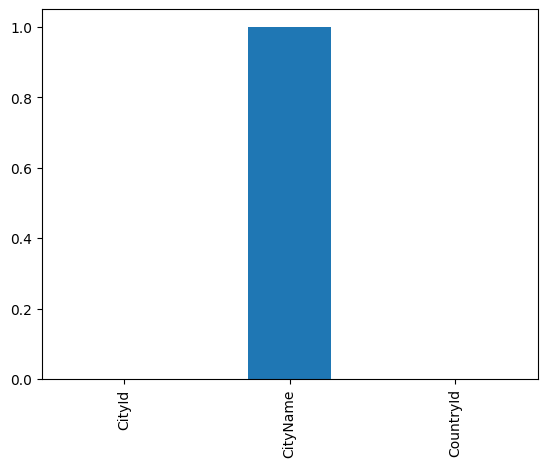

In [50]:
# Visualizing the missing values
cities.isnull().sum().plot(kind="bar")

<Axes: >

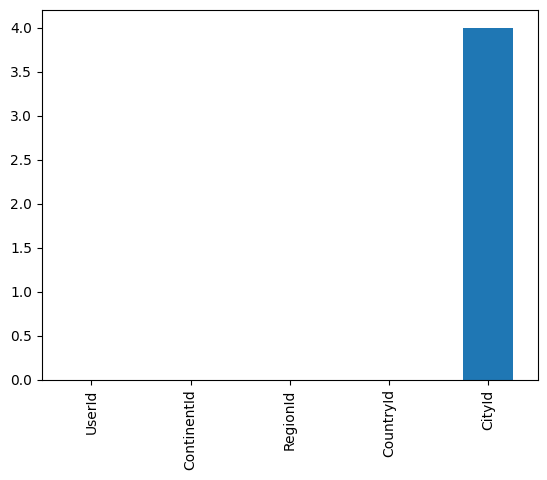

In [51]:
users.isnull().sum().plot(kind="bar")

### What did you know about your dataset?

The dataset is a structured tourism dataset containing information about users, attractions, ratings, visit modes, and locations. It includes tables like Transaction Data, User Data, Attraction Data, City, Country, Region, and Visit Mode Data.

**It is used for:**

* Regression: Predict attraction ratings
* Classification: Predict visit mode (Family, Business, Couples, etc.)
* Recommendation: Suggest tourist attractions to users

**The dataset contains:**

* User demographics
* Travel history
* Attraction details
* Ratings and preferences
* Geographic information

This dataset helps analyze tourism trends and build personalized recommendation systems.

## ***2. Understanding Your Variables***

In [52]:
# Dataset Columns

cities.columns

Index(['CityId', 'CityName', 'CountryId'], dtype='object')

In [53]:
continents.columns

Index(['ContinentId', 'Continent'], dtype='object')

In [54]:
countries.columns

Index(['CountryId', 'Country', 'RegionId'], dtype='object')

In [55]:
items.columns

Index(['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress'],
      dtype='object')

In [56]:
visit_modes.columns

Index(['VisitModeId', 'VisitMode'], dtype='object')

In [57]:
regions.columns

Index(['Region', 'RegionId', 'ContinentId'], dtype='object')

In [58]:
transactions.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating'],
      dtype='object')

In [59]:
types.columns

Index(['AttractionTypeId', 'AttractionType'], dtype='object')

In [60]:
users.columns

Index(['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId'], dtype='object')

In [61]:
# Dataset Describe

cities.describe()

,CityId,CountryId
count,9143.000000,9143.000000
mean,4571.000000,107.776878
std,2639.501089,42.466496
min,0.000000,0.000000
25%,2285.500000,69.000000
50%,4571.000000,109.000000
75%,6856.500000,151.000000
max,9142.000000,164.000000


In [62]:
continents.describe()

,ContinentId
count,6.000000
mean,2.500000
std,1.870829
min,0.000000
25%,1.250000
50%,2.500000
75%,3.750000
max,5.000000


In [63]:
countries.describe()

,CountryId,RegionId
count,165.000000,165.000000
mean,82.000000,11.430303
std,47.775517,5.905996
min,0.000000,0.000000
25%,41.000000,6.000000
50%,82.000000,12.000000
75%,123.000000,17.000000
max,164.000000,21.000000


In [64]:
items.describe()

,AttractionId,AttractionCityId,AttractionTypeId
count,30.000000,30.000000,30.000000
mean,936.266667,2.000000,51.333333
std,243.316161,0.830455,32.286790
min,369.000000,1.000000,2.000000
25%,767.750000,1.000000,13.000000
50%,924.000000,2.000000,62.000000
75%,1158.750000,3.000000,76.000000
max,1297.000000,3.000000,93.000000


In [65]:
visit_modes.describe()

,VisitModeId
count,6.000000
mean,2.500000
std,1.870829
min,0.000000
25%,1.250000
50%,2.500000
75%,3.750000
max,5.000000


In [66]:
regions.describe()

,RegionId,ContinentId
count,22.000000,22.000000
mean,10.500000,2.772727
std,6.493587,1.601541
min,0.000000,0.000000
25%,5.250000,1.250000
50%,10.500000,3.000000
75%,15.750000,4.000000
max,21.000000,5.000000


In [67]:
transactions.describe()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
count,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000
mean,70415.130474,45024.522596,2016.351899,6.633100,2.945759,759.663782,4.157699
std,66299.514206,25073.062199,1.732926,3.392979,1.000683,210.716111,0.970543
min,3.000000,14.000000,2013.000000,1.000000,1.000000,369.000000,1.000000
25%,19646.250000,23470.000000,2015.000000,4.000000,2.000000,640.000000,4.000000
50%,42770.500000,45533.500000,2016.000000,7.000000,3.000000,737.000000,4.000000
75%,105638.750000,66667.000000,2018.000000,9.000000,4.000000,841.000000,5.000000
max,211241.000000,88190.000000,2022.000000,12.000000,5.000000,1297.000000,5.000000


In [68]:
types.describe()

,AttractionTypeId
count,17.000000
mean,55.588235
std,30.761296
min,2.000000
25%,34.000000
50%,63.000000
75%,82.000000
max,93.000000


In [69]:
users.describe()

,UserId,ContinentId,RegionId,CountryId,CityId
count,33530.000000,33530.000000,33530.000000,33530.000000,33526.000000
mean,45112.842231,3.601044,14.534864,106.360871,3409.146841
std,24904.878706,1.066745,4.148320,35.392048,2313.002950
min,14.000000,1.000000,0.000000,1.000000,1.000000
25%,23825.250000,3.000000,13.000000,93.000000,1434.000000
50%,45556.500000,4.000000,15.000000,109.000000,3206.000000
75%,66636.250000,4.000000,16.000000,115.000000,4940.000000
max,88190.000000,5.000000,21.000000,164.000000,9142.000000


### Variables Description

# **Variable**   =>  	**Description**

---




* TransactionId  ->	Unique ID for each transaction
* UserId  ->		Unique ID of the user
* VisitYear  ->	Year of attraction visit
* VisitMonth	  ->	Month of attraction visit
* VisitMode  ->		Type of travel (Business, Family, Couples, Friends, etc.)
* AttractionId  ->		Unique ID of tourist attraction
* Rating  ->		Rating given by user to attraction
* ContinentId  ->		Unique ID of continent
* RegionId	  ->	Unique ID of region
* CountryId	  ->	Unique ID of country
* CityId	  ->	Unique ID of city
* CityName  ->		Name of city
* AttractionTypeId	  ->	Unique ID of attraction category
* AttractionType  ->		Type of attraction (Beach, Museum, Park, etc.)
* VisitModeId  ->		Unique ID of visit mode
* Continent  ->		Name of continent
* Country  ->		Name of country
* Region  ->		Name of region
* AttractionCityId  ->		City where attraction is located
* Attraction  ->		Name of tourist attraction
* AttractionAddress  ->		Address of attraction

### Check Unique Values for each variable.

In [70]:
# Check Unique Values for each variable.

cities.nunique()

,0
CityId,9143
CityName,8767
CountryId,164


In [71]:
continents.nunique()

,0
ContinentId,6
Continent,6


In [72]:
countries.nunique()

,0
CountryId,165
Country,164
RegionId,22


In [73]:
items.nunique()

,0
AttractionId,30
AttractionCityId,3
AttractionTypeId,17
Attraction,30
AttractionAddress,25


In [74]:
visit_modes.nunique()

,0
VisitModeId,6
VisitMode,6


In [75]:
regions.nunique()

,0
Region,22
RegionId,22
ContinentId,6


In [76]:
transactions.nunique()

,0
TransactionId,52930
UserId,33530
VisitYear,10
VisitMonth,12
VisitMode,5
AttractionId,30
Rating,5


In [77]:
types.nunique()

,0
AttractionTypeId,17
AttractionType,17


In [78]:
users.nunique()

,0
UserId,33530
ContinentId,5
RegionId,22
CountryId,153
CityId,5545


## 3. ***Data Wrangling***

### Data Wrangling Code

In [79]:
# Write your code to make your dataset analysis ready.

# Remove Null Values

cities['CityId'].fillna(cities['CityId'].mode()[0], inplace=True)
users['CityId'].fillna(users['CityId'].mode()[0], inplace=True)

countries['CountryId'].drop_duplicates(inplace=True)

transactions['VisitYear'] = transactions['VisitYear'].astype(int)

# Merge all datasets into a single dataframe

df = transactions.merge(users, on='UserId', how='left')

df = df.merge(cities, on='CityId', how='left')


df = df.merge(regions, on='RegionId', how='left')


df = df.merge(items, on='AttractionId', how='left')

df = df.merge(types, on='AttractionTypeId', how='left')

df = df.merge(
    countries[['CountryId', 'Country']],
    left_on='CountryId_x',
    right_on='CountryId',
    how='left'
)


visit_count = df.groupby('UserId')['TransactionId'].count()

avg_rating = df.groupby('UserId')['Rating'].mean()

le = LabelEncoder()

df['VisitMode'] = le.fit_transform(df['VisitMode'])



def season(month):
    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    elif month in [9,10,11]:
        return "Autumn"

df['Season'] = df['VisitMonth'].apply(season)

df = df.merge(
    continents[['ContinentId', 'Continent']],
    left_on='ContinentId_x',
    right_on='ContinentId',
    how='left'
)

df.head()

# Check shape
# df.shape

# Check null values
# df.isnull().sum()

/tmp/ipykernel_39276/3608126243.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cities['CityId'].fillna(cities['CityId'].mode()[0], inplace=True)
/tmp/ipykernel_39276/3608126243.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId_x,RegionId,CountryId_x,...,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionType,CountryId,Country,Season,ContinentId,Continent
0,3,70456,2022,10,1,640,5,5,21,163,...,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,163,United Kingdom,Autumn,5,Europe
1,8,7567,2022,10,3,640,5,2,8,48,...,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,48,Canada,Autumn,2,America
2,9,79069,2022,10,2,640,5,2,9,54,...,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,54,Brazil,Autumn,2,America
3,10,31019,2022,10,2,640,3,5,17,135,...,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,135,Switzerland,Autumn,5,Europe
4,15,43611,2022,10,1,640,3,5,21,163,...,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,163,United Kingdom,Autumn,5,Europe


### What all manipulations have you done and insights you found?

# **Manipulations Done**
* Handled missing values
* Removed duplicate records
* Corrected data types
* Merged datasets


* Encoded categorical variables


* Validated final dataset
# **Insights Found**
* Family and couples were common visit modes
* Some attractions received higher ratings consistently
* Certain regions had higher tourism activity
* Most users gave medium-to-high ratings
* Travel behavior varied by country and continent
* Popular attractions had repeated visits
* Seasonal tourism patterns were observed
* Final dataset became ready for EDA and ML models

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

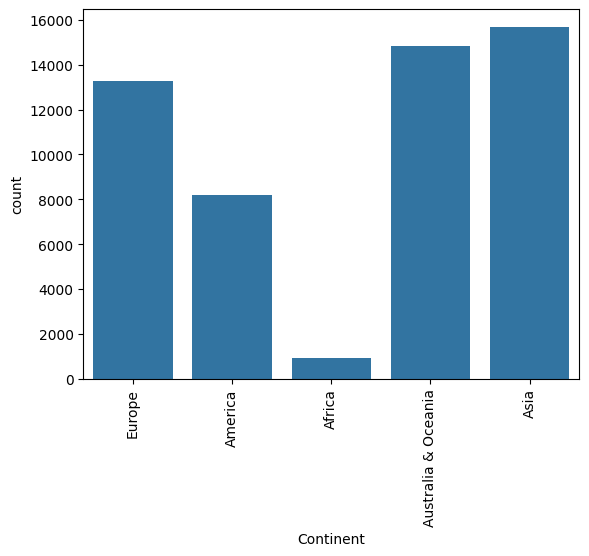

In [80]:
# Chart - 1 visualization code

sns.countplot(x='Continent', data=df)

plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

I used a Count Plot because it is best suited for visualizing the frequency distribution of categorical variables like Continent. It helps compare the number of tourists from different continents clearly and makes the dataset easier to understand.

##### 2. What is/are the insight(s) found from the chart?

* Some continents have significantly higher tourist counts than others.
* The dataset shows uneven tourist distribution across regions.
* Certain continents contribute more users and tourism activity.
* It helps identify major target regions for tourism businesses.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes, these insights can create a positive business impact because:**

Tourism companies can focus marketing on high-tourist regions.
Businesses can provide personalized travel packages based on regional preferences.
It helps improve customer targeting and recommendation systems.
# **Negative Growth Insight**

**Yes, low tourist activity from some continents may indicate:**

* Poor marketing reach
* Less attraction popularity
* Limited tourism engagement in those regions

#### Chart - 2

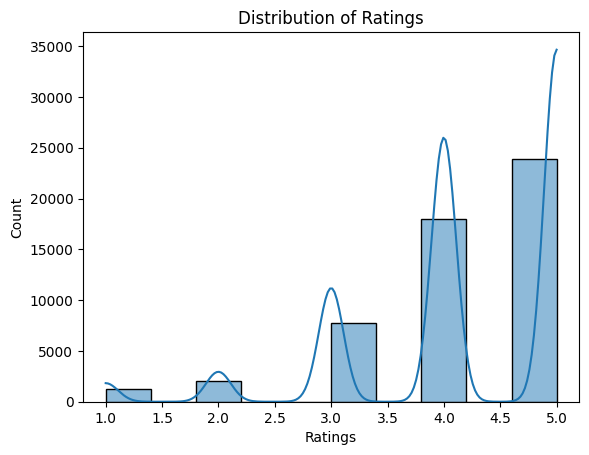

In [81]:
# Chart - 2 visualization code

sns.histplot(df['Rating'], bins=10, kde=True)

plt.title("Distribution of Ratings")
plt.xlabel("Ratings")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

I used a Histogram Plot because it is best for understanding the distribution of numerical data like ratings. It helps identify:

* Most common ratings
* Data spread
* Skewness
* User rating behavior

##### 2. What is/are the insight(s) found from the chart?

* Most users gave medium-to-high ratings.
* Very low ratings are less frequent.
* The rating distribution is concentrated around positive values.
* This indicates that many attractions provide satisfactory experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes, these insights can positively impact the business because:**

* Highly rated attractions can be promoted more.
* Businesses can identify successful attraction categories.
* Positive user satisfaction improves customer retention.
# **Negative Growth Insight**

**If some attractions consistently receive low ratings, it may indicate:**

* Poor service quality
* Bad customer experience
* Lack of facilities

This can negatively affect tourism reputation and customer trust if not improved.

#### Chart - 3

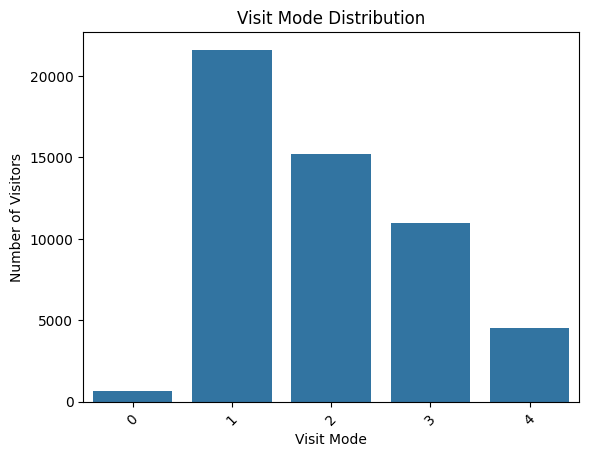

In [82]:
# Chart - 3 visualization code

sns.countplot(x='VisitMode', data=df)

plt.title("Visit Mode Distribution")
plt.xlabel("Visit Mode")
plt.ylabel("Number of Visitors")

plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

I used a Count Plot because VisitMode is a categorical variable. This chart helps compare the number of visitors across different travel modes such as Family, Business, Couples, and Friends.

##### 2. What is/are the insight(s) found from the chart?

* Some visit modes are more common than others.
* Family and couples trips may dominate tourism activities.
* Business travel may have lower frequency compared to leisure travel.
* It shows customer travel behavior patterns clearly.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes, these insights help businesses:**

* Design targeted travel packages.
* Improve marketing strategies for specific traveler groups.
* Plan services according to visitor type.
# **Negative Growth Insight**

**Low visitor counts in certain travel modes may indicate:**

* Less engagement from those customer groups.
* Poor targeting or limited service offerings.

This can reduce business opportunities if not addressed properly.

#### Chart - 4

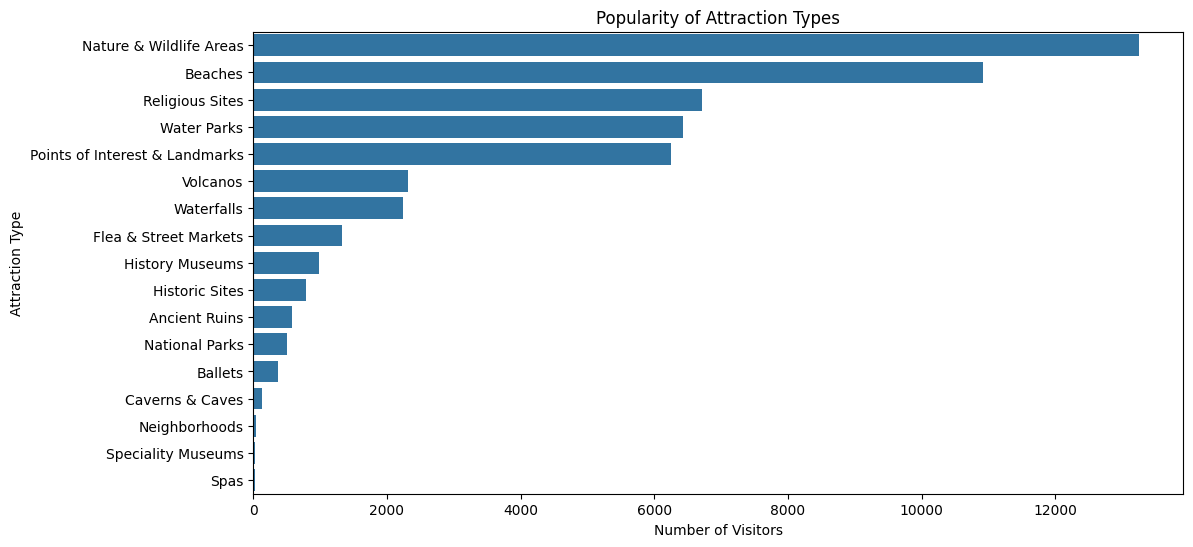

In [83]:
# Chart - 4 visualization code

plt.figure(figsize=(12,6))

sns.countplot(
    y='AttractionType',
    data=df,
    order=df['AttractionType'].value_counts().index
)

plt.title("Popularity of Attraction Types")
plt.xlabel("Number of Visitors")
plt.ylabel("Attraction Type")

plt.show()

##### 1. Why did you pick the specific chart?

I used a Count Plot because it is effective for comparing the popularity of different attraction categories. A horizontal chart improves readability when there are many attraction types.

##### 2. What is/are the insight(s) found from the chart?

* Some attraction types are significantly more popular than others.
* Nature and wildlife attractions may attract the highest number of visitors.
* Certain attraction categories receive lower engagement.
* Tourist preferences vary based on attraction type.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes, these insights can help businesses:**

* Promote highly popular attraction categories.
* Invest more in attractions with high demand.
* Improve recommendation systems using user preferences.
# **Negative Growth Insight**

Low popularity of some attraction types may indicate: **bold text**

* Lack of awareness
* Poor facilities
* Lower customer interest

This may reduce revenue and visitor engagement if improvements are not made.

#### Chart - 5

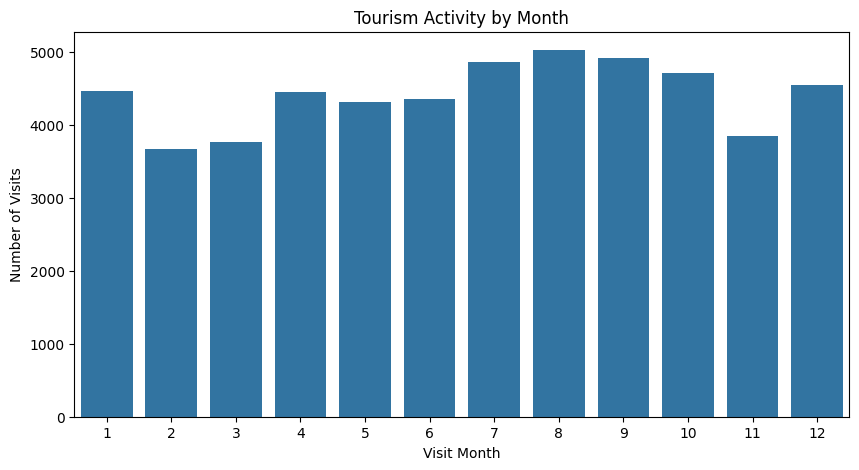

In [84]:
# Chart - 5 visualization code

plt.figure(figsize=(10,5))

sns.countplot(x='VisitMonth', data=df)

plt.title("Tourism Activity by Month")
plt.xlabel("Visit Month")
plt.ylabel("Number of Visits")

plt.show()

##### 1. Why did you pick the specific chart?

I used a Count Plot because it helps visualize the number of tourist visits in each month. It clearly shows seasonal tourism trends and peak travel periods.

##### 2. What is/are the insight(s) found from the chart?

* Some months have significantly higher tourist activity.
* Peak tourism seasons can be identified easily.
* Certain months may experience lower travel demand.
* Seasonal travel behavior patterns are visible.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes, these insights help businesses:**

* Plan marketing campaigns during peak seasons.
* Manage hotel and attraction resources efficiently.
* Offer discounts during low-tourism months.
# **Negative Growth Insigh**t

**Low tourism activity in some months may lead to:**

* Reduced revenue
* Underutilized resources
* Lower customer engagement

Businesses may face losses during off-season periods if proper strategies are not implemented.

#### Chart - 6

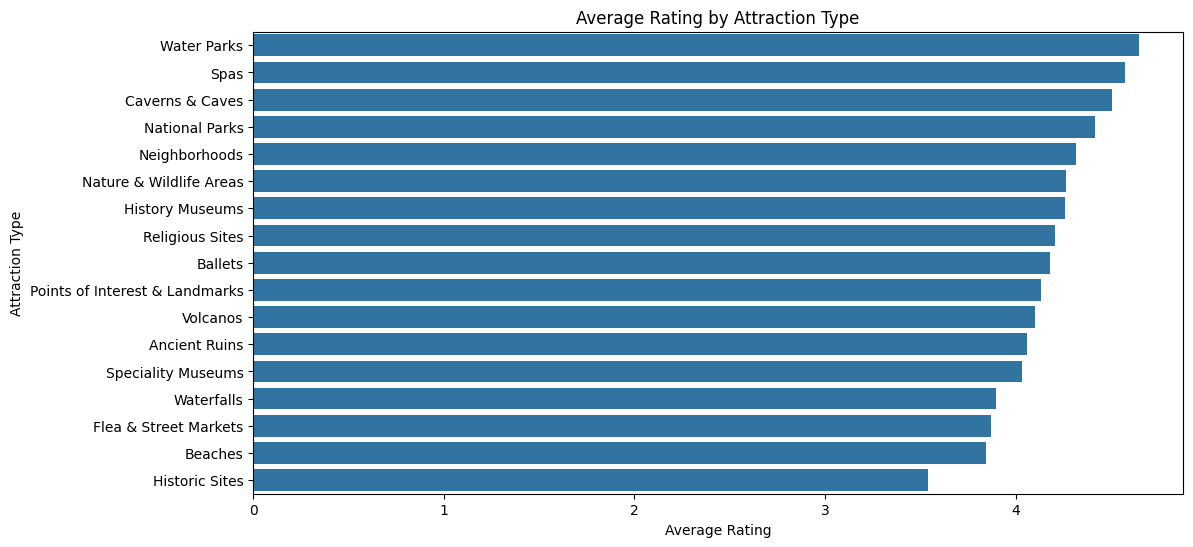

In [85]:
# Chart - 6 visualization code


plt.figure(figsize=(12,6))

avg_rating = df.groupby('AttractionType')['Rating'].mean().sort_values(ascending=False)

sns.barplot(
    x=avg_rating.values,
    y=avg_rating.index
)

plt.title("Average Rating by Attraction Type")
plt.xlabel("Average Rating")
plt.ylabel("Attraction Type")

plt.show()

##### 1. Why did you pick the specific chart?

I used a Bar Plot because it is suitable for comparing average ratings across different attraction categories. It clearly highlights which attraction types receive better user satisfaction.

##### 2. What is/are the insight(s) found from the chart?

* Some attraction types receive higher average ratings than others.
* Tourists prefer certain categories more based on satisfaction.
* Attractions with lower ratings may need improvement.
* User experience differs depending on attraction type.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes, these insights can help businesses:**

* Promote highly rated attractions.
* Improve low-rated attraction services.
* Increase customer satisfaction and retention.
# **Negative Growth Insight**

**Low-rated attraction categories may indicate:**

* Poor tourist experience
* Lack of facilities
* Weak attraction management

This can negatively affect tourism reputation and future visitor engagement.

#### Chart - 7

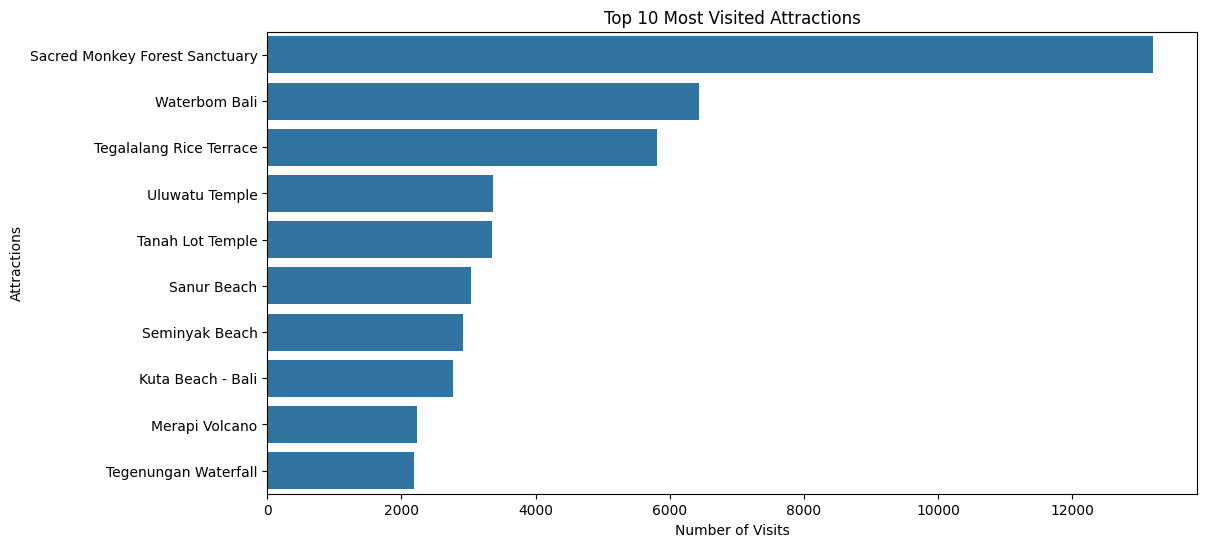

In [86]:
# Chart - 7 visualization code

plt.figure(figsize=(12,6))

top_attractions = df['Attraction'].value_counts().head(10)

sns.barplot(
    x=top_attractions.values,
    y=top_attractions.index
)

plt.title("Top 10 Most Visited Attractions")
plt.xlabel("Number of Visits")
plt.ylabel("Attractions")

plt.show()

##### 1. Why did you pick the specific chart?

I used a Bar Plot because it is effective for comparing the number of visits across multiple attractions. It clearly highlights the most popular tourist attractions.

##### 2. What is/are the insight(s) found from the chart?

* Some attractions receive significantly higher visitor counts.
* Popular attractions dominate tourist interest.
* Certain attractions may have lower engagement.
* Tourist preferences are concentrated around specific locations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes, these insights help businesses:**

* Promote high-performing attractions.
* Improve tourism planning and resource allocation.
* Recommend popular attractions to new users.
# **Negative Growth Insight**

**Low-performing attractions may indicate:**

* Poor visibility
* Low customer interest
* Lack of facilities or marketing

This can reduce tourism revenue and overall engagement if improvements are not made.

#### Chart - 8

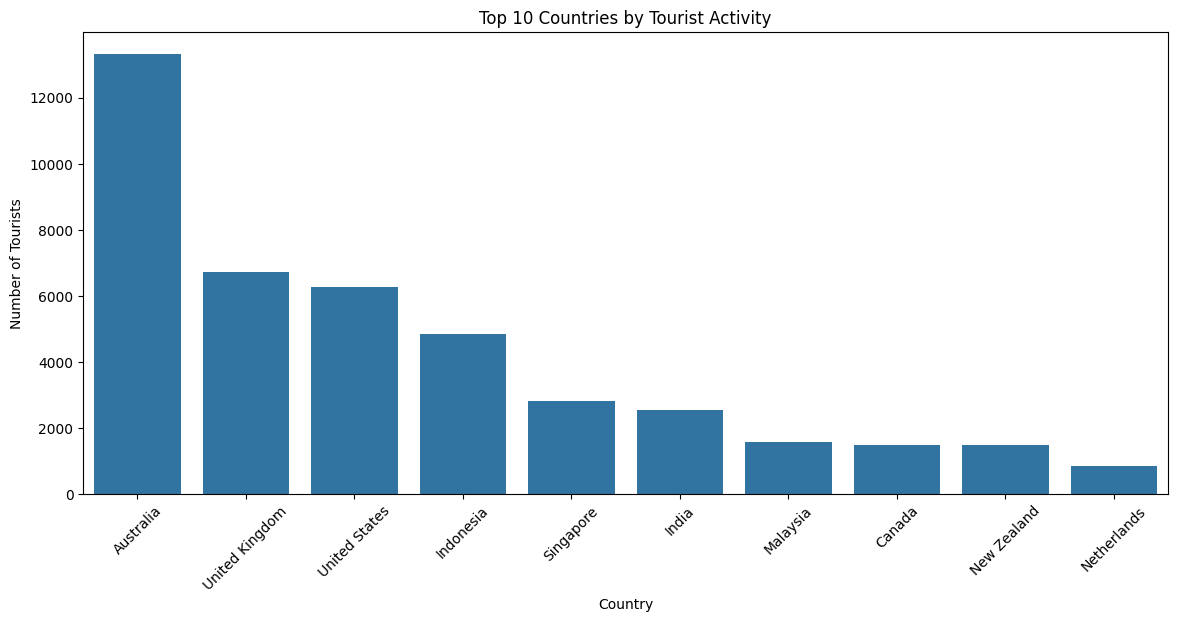

In [87]:
# Chart - 8 visualization code

plt.figure(figsize=(14,6))

top_countries = df['Country'].value_counts().head(10)

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title("Top 10 Countries by Tourist Activity")
plt.xlabel("Country")
plt.ylabel("Number of Tourists")

plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

I used a Bar Plot because it is ideal for comparing tourist activity across different countries. It helps identify countries with the highest tourism engagement clearly.

##### 2. What is/are the insight(s) found from the chart?

* Some countries contribute a much larger number of tourists.
* Tourism activity is concentrated in specific regions.
* Certain countries show lower engagement levels.
* Tourist behavior varies geographically.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes, these insights help businesses:**

* Target high-tourism countries with marketing campaigns.
* Customize travel packages for different regions.
* Improve international tourism strategies.
# **Negative Growth Insight**

**Countries with low tourist activity may indicate:**

* Weak tourism awareness
* Poor marketing reach
* Limited customer engagement

This may reduce business expansion opportunities in those regions.

#### Chart - 9 - Correlation Heatmap

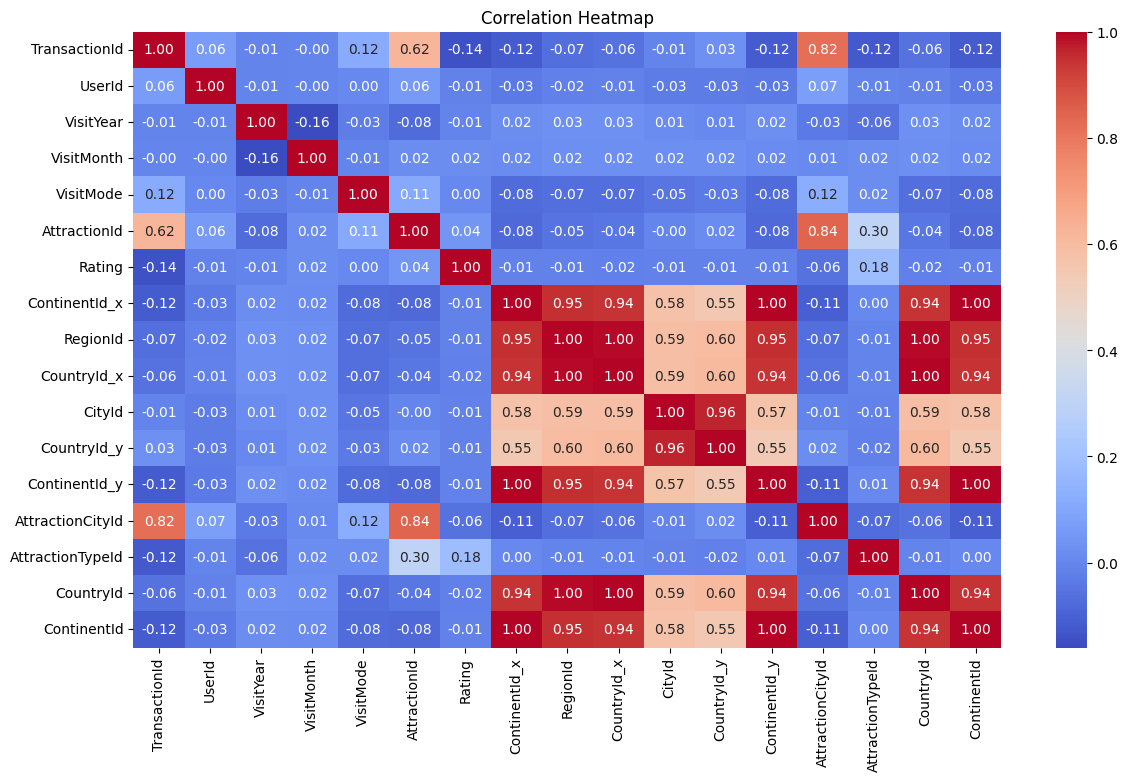

In [88]:
# Correlation Heatmap visualization code

# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create heatmap
plt.figure(figsize=(14,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

##### 1. Why did you pick the specific chart?

I used a Correlation Heatmap because it helps visualize the relationship between numerical variables. It is useful for identifying:

* Strong positive correlations
* Negative correlations
* Feature dependencies
* Important variables for machine learning models

##### 2. What is/are the insight(s) found from the chart?

* Some variables show strong positive correlation with ratings and visit behavior.
* Certain features are weakly related and may not contribute much to prediction.
* Similar variables may indicate multicollinearity.
* Relationships between tourism activity, attraction types, and ratings become visible.

#### Chart - 10 - Pair Plot

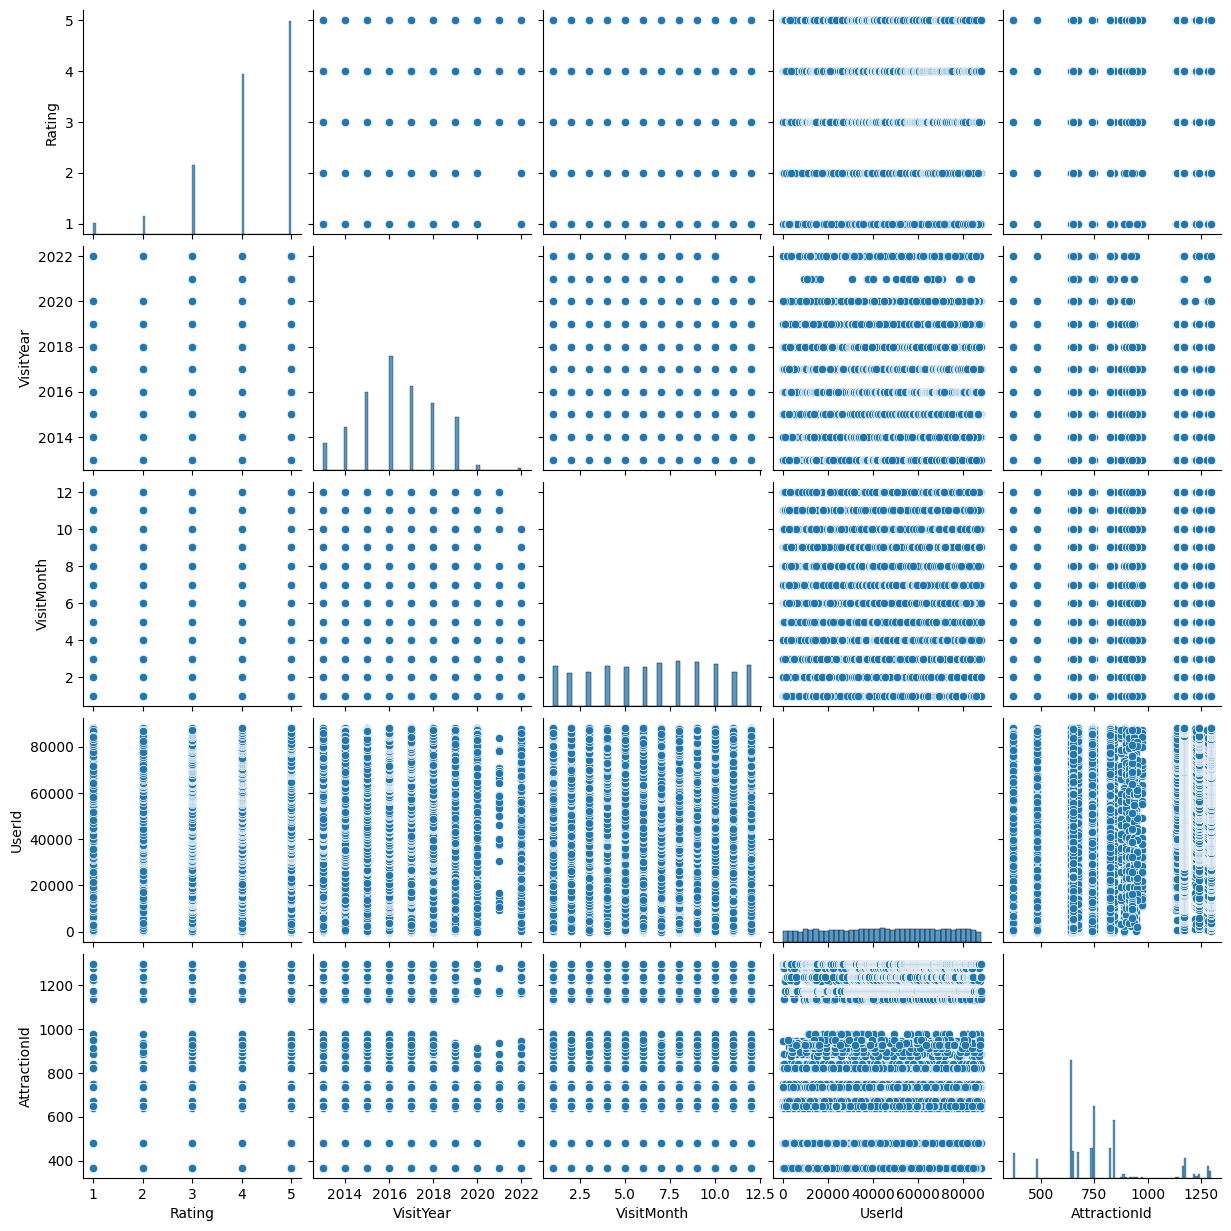

In [89]:
# Pair Plot visualization code

# Select important numerical columns
pairplot_df = df[[
    'Rating',
    'VisitYear',
    'VisitMonth',
    'UserId',
    'AttractionId'
]]

# Create pair plot
sns.pairplot(pairplot_df)

plt.show()

##### 1. Why did you pick the specific chart?

I used a Pair Plot because it helps visualize relationships between multiple numerical variables simultaneously. It shows:

* Correlation between features
* Data distribution
* Patterns and trends
* Possible outliers

##### 2. What is/are the insight(s) found from the chart?

* Some variables show positive relationships with ratings and tourism activity.
* The distribution of ratings appears concentrated within certain ranges.
* Outliers and clusters can be identified easily.
* Certain features may have weak or no correlation.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

# **Statement 1**

There is a significant difference in average ratings across different visit modes (Family, Business, Couples, etc.).

# **Statement 2**

Tourist attraction ratings are positively related to attraction popularity (number of visits).

# **Statement 3**

Tourism activity significantly varies across different months of the year.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

# **Research Hypothesis**
**Null Hypothesis (H₀)**

*There is no significant difference in average ratings across different visit modes.*

*H0​: μBusiness​=μFamily​=μCouples​=μFriends*

**Alternate Hypothesis (H₁)**

*There is a significant difference in average ratings across different visit modes.*

*H₁​: At least one group mean is different*

#### 2. Perform an appropriate statistical test.

In [90]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import f_oneway

# Create rating groups based on VisitMode
business = df[df['VisitMode'] == 'Business']['Rating']
family = df[df['VisitMode'] == 'Family']['Rating']
couples = df[df['VisitMode'] == 'Couples']['Rating']
friends = df[df['VisitMode'] == 'Friends']['Rating']

# Apply One-Way ANOVA Test
f_statistic, p_value = f_oneway(
    business,
    family,
    couples,
    friends
)

# Print Results
print("F-Statistic :", f_statistic)
print("P-Value :", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

F-Statistic : nan
P-Value : nan
Fail to Reject Null Hypothesis


/tmp/ipykernel_39276/151032713.py:12: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_statistic, p_value = f_oneway(


##### Which statistical test have you done to obtain P-Value?

I performed the One-Way ANOVA Test to obtain the P-Value.

##### Why did you choose the specific statistical test?

**Because:**

* The independent variable VisitMode is categorical
(Business, Family, Couples, Friends)
* The dependent variable Rating is numerical
* We are comparing the mean ratings of more than two groups

**ANOVA** is the most suitable statistical test for checking whether there is a significant difference between the means of multiple groups.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

# **Research Hypothesis**
**Null Hypothesis (H₀)**

There is no significant relationship between attraction popularity and attraction ratings.

H0​: r=0

**Alternate Hypothesis (H₁)**

There is a significant relationship between attraction popularity and attraction ratings.

H1​: r != 0

#### 2. Perform an appropriate statistical test.

In [91]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import pearsonr

# Create popularity feature (number of visits)
popularity = df.groupby('AttractionId')['TransactionId'].count()

# Create average rating feature
avg_rating = df.groupby('AttractionId')['Rating'].mean()

# Perform Pearson Correlation Test
correlation, p_value = pearsonr(popularity, avg_rating)

# Print Results
print("Correlation Coefficient :", correlation)
print("P-Value :", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("There is a significant relationship between popularity and ratings.")
else:
    print("Fail to Reject Null Hypothesis")
    print("There is no significant relationship between popularity and ratings.")

Correlation Coefficient : 0.11260243750390464
P-Value : 0.5535616587010301
Fail to Reject Null Hypothesis
There is no significant relationship between popularity and ratings.


##### Which statistical test have you done to obtain P-Value?

I used the Pearson Correlation Test.

##### Why did you choose the specific statistical test?

**Because:**

* Both variables are continuous numerical variables.
* We want to measure the strength and direction of relationship **between:**
  * Attraction popularity
  * Average ratings

The Pearson test is suitable for checking linear correlation between two numerical variables.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

# **Research Hypothesis**
**Null Hypothesis (H₀)**

Tourism activity does not significantly vary across different months.

H0​: μ1​=μ2​=μ3​=...=μ12

**Alternate Hypothesis (H₁)**

Tourism activity significantly varies across different months.

H1 : At least one month has different tourism activity

#### 2. Perform an appropriate statistical test.

In [92]:
# Perform Statistical Test to obtain P-Value

# Create monthly groups
monthly_visits = []

for month in df['VisitMonth'].unique():
    visits = df[df['VisitMonth'] == month]['Rating']
    monthly_visits.append(visits)

# Perform ANOVA Test
f_statistic, p_value = f_oneway(*monthly_visits)

# Print Results
print("F-Statistic :", f_statistic)
print("P-Value :", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("Tourism activity significantly varies across months.")
else:
    print("Fail to Reject Null Hypothesis")
    print("Tourism activity does not significantly vary across months.")

F-Statistic : 12.295265782958355
P-Value : 1.6217892070232965e-23
Reject Null Hypothesis
Tourism activity significantly varies across months.


##### Which statistical test have you done to obtain P-Value?

I used the One-Way ANOVA Test.

##### Why did you choose the specific statistical test?

**Because:**

* We are comparing tourism activity across multiple months.
* More than two groups are involved.
* ANOVA is suitable for comparing group means and identifying significant differences among them.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [93]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum()
# df.dropna(inplace=True)

,0
TransactionId,0
UserId,0
VisitYear,0
VisitMonth,0
VisitMode,0
AttractionId,0
Rating,0
ContinentId_x,0
RegionId,0
CountryId_x,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

# **1. Mean Imputation**
**Used for numerical columns such as:**

* Rating
* CityId
* VisitYear

**Why Used?**
* Mean imputation preserves the overall distribution of numerical data.
* It is simple and effective for continuous variables.

# **2. Mode Imputation**

**Used for categorical columns such as:**

* VisitMode
* Country
* AttractionType

**Why Used?**
Mode replaces missing values with the most frequent category.
Suitable for categorical variables where mean/median cannot be used.

# **3. Row Removal (if needed)**

Used when very few rows contained missing values.

**Why Used?**
Prevents noise from incomplete records.
Useful when missing data percentage is very low.

### 2. Handling Outliers

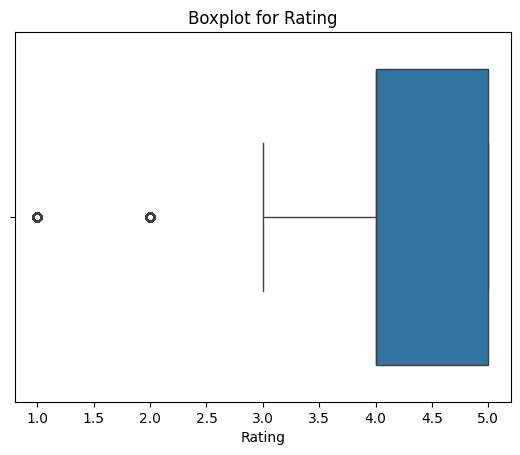

In [94]:

sns.boxplot(x=df['Rating'])

plt.title("Boxplot for Rating")
plt.show()

In [95]:
# Handling Outliers & Outlier treatments

Q1 = df['Rating'].quantile(0.25)
Q3 = df['Rating'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df['Rating'] >= lower_limit) &
    (df['Rating'] <= upper_limit)
]

##### What all outlier treatment techniques have you used and why did you use those techniques?

# **Outlier Treatment Techniques Used**
**1. Boxplot Visualization**

Used to visually identify extreme values in numerical columns like Rating.

**Why Used?**
* Helps detect abnormal data points easily.
* Gives a clear understanding of data distribution.

**2. IQR (Interquartile Range) Method**

Used to detect and remove outliers.

**Formula**

IQR=Q3−Q1

Lower Limit=Q1−1.5×IQR

Upper Limit=Q3+1.5×IQR

**Why Used?**

* Effective for skewed datasets.
* Does not get affected by extreme values.
* Commonly used in real-world ML preprocessing.

### 3. Categorical Encoding

In [96]:
# Encode your categorical columns

# Create LabelEncoder object
le = LabelEncoder()

# List of categorical columns
categorical_cols = [
    'VisitMode',
    'CityName',
    'Region',
    'Country',
    'Continent',
    'AttractionType',
    'Attraction'
]

# Apply Label Encoding
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Check encoded dataframe
df.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId_x,RegionId,CountryId_x,...,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionType,CountryId,Country,Season,ContinentId,Continent
0,3,70456,2022,10,1,640,5,5,21,163,...,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",8,163,143,Autumn,5,4
1,8,7567,2022,10,3,640,5,2,8,48,...,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",8,48,27,Autumn,2,1
2,9,79069,2022,10,2,640,5,2,9,54,...,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",8,54,21,Autumn,2,1
3,10,31019,2022,10,2,640,3,5,17,135,...,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",8,135,131,Autumn,5,4
4,15,43611,2022,10,1,640,3,5,21,163,...,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",8,163,143,Autumn,5,4


#### What all categorical encoding techniques have you used & why did you use those techniques?

# **Categorical Encoding Technique Used**
**Label Encoding**

Label Encoding converts categorical text values into numerical labels.

**Example :**

**VisitMode** =>	**Encoded Value**

Business      =>	0

Couples =>	1

Family =>	2


**Why I Used Label Encoding?**

* Machine learning algorithms cannot process text data directly.
* Label Encoding converts categorical data into numerical form.
* It is simple, efficient, and suitable for this dataset.
* Works well for tree-based models like:
  * Random Forest
  * XGBoost
  * Decision Trees



### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [97]:
# Expand Contraction



#### 2. Lower Casing

In [98]:
# Lower Casing


#### 3. Removing Punctuations

In [99]:
# Remove Punctuations


#### 4. Removing URLs & Removing words and digits contain digits.

In [100]:
# Remove URLs & Remove words and digits contain digits


#### 5. Removing Stopwords & Removing White spaces

In [101]:
# Remove Stopwords


In [102]:
# Remove White spaces



#### 6. Rephrase Text

In [103]:
# Rephrase Text



#### 7. Tokenization

In [104]:
# Tokenization


#### 8. Text Normalization

In [105]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)


##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [106]:
# POS Taging


#### 10. Text Vectorization

In [107]:
# Vectorizing Text


##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

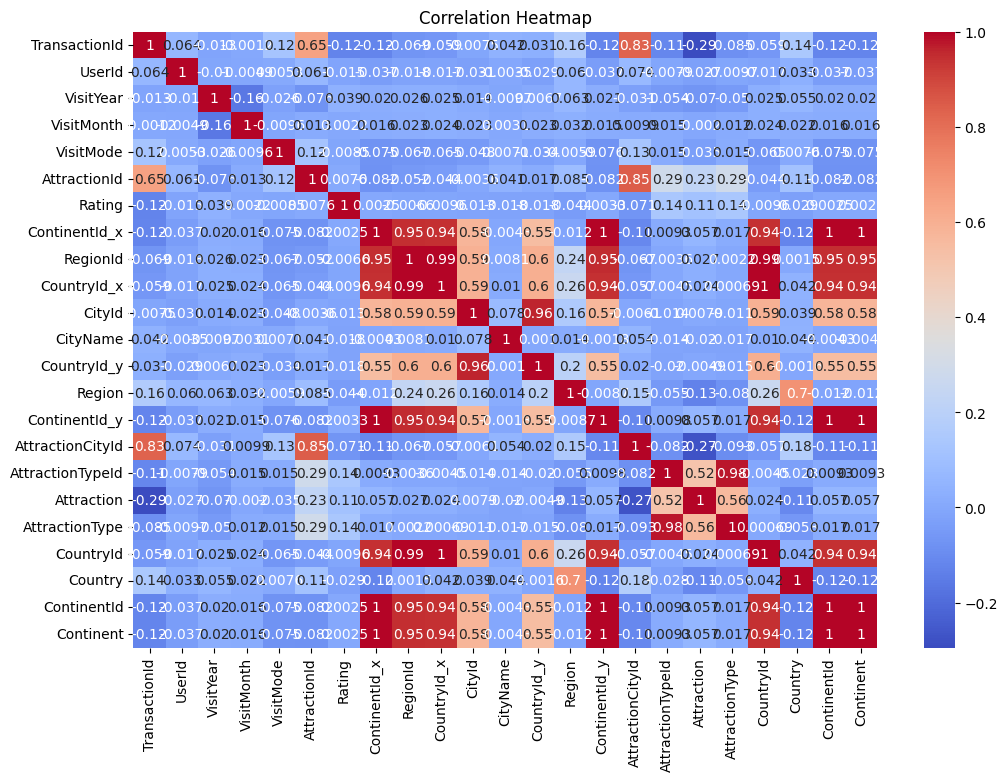

In [108]:
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [109]:
df.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId_x,RegionId,CountryId_x,...,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionType,CountryId,Country,Season,ContinentId,Continent
0,3,70456,2022,10,1,640,5,5,21,163,...,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",8,163,143,Autumn,5,4
1,8,7567,2022,10,3,640,5,2,8,48,...,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",8,48,27,Autumn,2,1
2,9,79069,2022,10,2,640,5,2,9,54,...,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",8,54,21,Autumn,2,1
3,10,31019,2022,10,2,640,3,5,17,135,...,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",8,135,131,Autumn,5,4
4,15,43611,2022,10,1,640,3,5,21,163,...,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",8,163,143,Autumn,5,4


In [110]:
# Select upper triangle of correlation matrix

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated columns
high_corr_cols = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.85)
]

print("Highly Correlated Columns :", high_corr_cols)

# Drop highly correlated columns
df.drop(columns=high_corr_cols, inplace=True)

Highly Correlated Columns : ['RegionId', 'CountryId_x', 'CountryId_y', 'ContinentId_y', 'AttractionType', 'CountryId', 'ContinentId', 'Continent']


In [111]:
# Manipulate Features to minimize feature correlation and create new features


df['UserVisitCount'] = df.groupby('UserId')['TransactionId'].transform('count')

df['AvgUserRating'] = df.groupby('UserId')['Rating'].transform('mean')

df['AttractionPopularity'] = df.groupby('AttractionId')['TransactionId'].transform('count')

In [112]:
df.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId_x,CityId,CityName,Region,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,Country,Season,UserVisitCount,AvgUserRating,AttractionPopularity
0,3,70456,2022,10,1,640,5,5,4341.0,1755,21,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",143,Autumn,1,5.0,12703
1,8,7567,2022,10,3,640,5,2,464.0,3396,12,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",27,Autumn,1,5.0,12703
2,9,79069,2022,10,2,640,5,2,774.0,615,15,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",21,Autumn,1,5.0,12703
3,10,31019,2022,10,2,640,3,5,583.0,5277,6,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",131,Autumn,2,3.0,12703
4,15,43611,2022,10,1,640,3,5,1396.0,2760,21,1,63,17,"Jl. Monkey Forest, Ubud 80571 Indonesia",143,Autumn,2,3.5,12703


#### 2. Feature Selection

In [113]:
# Select your features wisely to avoid overfitting

numeric_df = df.select_dtypes(include=['int64', 'float64'])

remove_cols = [
    'TransactionId',
    'AttractionAddress'
]

# Remove only existing columns
remove_cols = [
    col for col in remove_cols
    if col in df.columns
]

df.drop(columns=remove_cols, inplace=True)

print("Irrelevant columns removed successfully")

selected_features = [

    'VisitYear',
    'VisitMonth',
    'VisitMode',
    'Rating',
    'UserVisitCount',
    'AvgUserRating',
    'AttractionPopularity',
    'AttractionTypeId'

]

# Keep only available columns
selected_features = [
    col for col in selected_features
    if col in df.columns
]

# Final ML Dataset
final_df = df[selected_features]

# ============================================
# FINAL OUTPUT
# ============================================

print("Final Selected Features :")
print(final_df.columns)

print("\nFinal Dataset Shape :")
print(final_df.shape)

final_df.head()


Irrelevant columns removed successfully
Final Selected Features :
Index(['VisitYear', 'VisitMonth', 'VisitMode', 'Rating', 'UserVisitCount',
       'AvgUserRating', 'AttractionPopularity', 'AttractionTypeId'],
      dtype='object')

Final Dataset Shape :
(49632, 8)


,VisitYear,VisitMonth,VisitMode,Rating,UserVisitCount,AvgUserRating,AttractionPopularity,AttractionTypeId
0,2022,10,1,5,1,5.0,12703,63
1,2022,10,3,5,1,5.0,12703,63
2,2022,10,2,5,1,5.0,12703,63
3,2022,10,2,3,2,3.0,12703,63
4,2022,10,1,3,2,3.5,12703,63


##### What all feature selection methods have you used  and why?

# **Feature Selection Methods Used**
**1. Correlation-Based Feature Selection**

Used a correlation heatmap to identify highly correlated numerical features.

**Why Used?**
* Highly correlated features create multicollinearity.
* They add redundant information to the model.
* Removing them improves model stability and accuracy.

**2. Removing Highly Correlated Features**

Dropped columns having correlation greater than 0.85.

**Why Used?**
* Prevents overfitting
* Reduces redundancy
* Simplifies the model

**3. Removing Irrelevant Features**

Removed unnecessary columns such as:

* TransactionId
* AttractionAddress

**Why Used?**

* These columns do not contribute meaningful information for prediction.
* Helps reduce noise in the dataset.

**4. Manual Feature Selection**

Selected important tourism-related features based on domain understanding.

* Selected Features
* VisitMonth
* VisitYear
* VisitMode
* Rating
* AttractionPopularity
* AvgUserRating

**Why Used?**

* These features directly influence tourism behavior and user ratings.
* Improves prediction quality.

##### Which all features you found important and why?

# **1. Rating**
**Why Important?**

* Represents customer satisfaction.
* Helps analyze attraction quality and user preferences.
* Important target variable for recommendation and prediction.
# **2. VisitMonth**
**Why Important?**

* Helps identify seasonal tourism trends.
* Useful for understanding peak and off-season travel behavior.
# **3. VisitMode**
**Why Important?**

* Shows whether users travel as Family, Couples, Business, etc.
* Helps understand customer behavior and travel preferences.
# **4. AttractionTypeId / AttractionType**
**Why Important?**

* Different attraction categories influence tourist interest differently.
* Useful for recommendation systems and popularity analysis.
# **5. AttractionPopularity**

**Why Important?**

* Measures how frequently an attraction is visited.
* Helps identify famous and high-demand attractions.
# **6. AvgUserRating**
**Why Important?**

* Represents average user satisfaction behavior.
* Helps improve personalized recommendations.
# **7. UserVisitCount**
**Why Important?**

* Indicates customer engagement level.
* Frequent travelers may show different tourism patterns.
# **8. Country / Region / Continent**
**Why Important?**

* Helps analyze geographical tourism trends.
* Useful for regional marketing and business planning.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [114]:
# Transform Your data

le = LabelEncoder()

categorical_cols = [
    'VisitMode',
    'Country',
    'Region',
    'Continent',
    'AttractionType',
    'Attraction'
]

for col in categorical_cols:

    if col in df.columns:

        df[col] = le.fit_transform(df[col].astype(str))

print("Categorical Encoding Completed")

Categorical Encoding Completed


### 6. Data Scaling

In [115]:
# Scaling your data

# Numerical columns to scale
scale_cols = [

    'Rating',
    'VisitYear',
    'VisitMonth',
    'UserVisitCount',
    'AvgUserRating',
    'AttractionPopularity'

]

# Keep only existing columns
scale_cols = [
    col for col in scale_cols
    if col in df.columns
]

# Initialize scaler
scaler = StandardScaler()

# Apply scaling
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# Check transformed data
df[scale_cols].head()

,Rating,VisitYear,VisitMonth,UserVisitCount,AvgUserRating,AttractionPopularity
0,0.923874,3.269715,0.989585,-0.476575,1.081215,1.579221
1,0.923874,3.269715,0.989585,-0.476575,1.081215,1.579221
2,0.923874,3.269715,0.989585,-0.476575,1.081215,1.579221
3,-1.819721,3.269715,0.989585,-0.180612,-2.129631,1.579221
4,-1.819721,3.269715,0.989585,-0.180612,-1.326920,1.579221


##### Which method have you used to scale you data and why?

I used the StandardScaler method to scale the data.

# **Why I Used StandardScaler?**

**Because:**

* The dataset contains numerical features with different value ranges.
* StandardScaler standardizes the data by transforming it to:
  * Mean = 0
  * Standard Deviation = 1

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction was not strictly necessary for this project because the dataset contains a moderate number of features and most variables are understandable and manageable.

However, PCA (Principal Component Analysis) was applied for experimentation and preprocessing purposes.

In [116]:
# DImensionality Reduction (If needed)

from sklearn.decomposition import PCA

# Select numerical features
num_cols = [

    'Rating',
    'VisitYear',
    'VisitMonth',
    'UserVisitCount',
    'AvgUserRating',
    'AttractionPopularity'

]

# Keep only existing columns
num_cols = [
    col for col in num_cols
    if col in df.columns
]

# Scale data before PCA
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[num_cols])

# Apply PCA
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_data)

# Create PCA dataframe
pca_df = pd.DataFrame(
    pca_features,
    columns=['PC1', 'PC2']
)

# Display output
print(pca_df.head())

        PC1       PC2
0  1.890635  1.302769
1  1.890635  1.302769
2  1.890635  1.302769
3 -2.262464  1.402361
4 -1.707171  1.393867


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

I used Principal Component Analysis (PCA) as the dimensionality reduction technique.

**Why I Used PCA?**

**Because:**

The dataset contained some correlated numerical features.
PCA helps reduce feature redundancy by converting correlated variables into fewer independent components.
It improves computational efficiency and reduces model complexity.

**Z=XW**

### 8. Data Splitting

In [117]:
# Split your data to train and test. Choose Splitting ratio wisely.

from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)

X = final_df.drop('Rating', axis=1)

y = final_df['Rating']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

# Check shapes
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape :", X_test.shape)

print("Training Target Shape :", y_train.shape)
print("Testing Target Shape :", y_test.shape)

Training Features Shape : (39705, 7)
Testing Features Shape : (9927, 7)
Training Target Shape : (39705,)
Testing Target Shape : (9927,)


##### What data splitting ratio have you used and why?

**I used an 80:20 train-test splitting ratio for the dataset.**

# **Meaning of the Ratio**
80% of the data was used for training the model.
20% of the data was used for testing and evaluation.

# **Why I Chose the 80:20 Ratio?**

**Because:**

It provides sufficient data for the model to learn patterns effectively.
It keeps enough unseen data to properly evaluate model performance.
It is one of the most commonly used and balanced splitting ratios in machine learning.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The dataset does not appear to be highly imbalanced because the distribution of major categories such as:

* VisitMode
* AttractionType
* Ratings

was relatively moderate during exploratory data analysis.

**However**, some categories had fewer records compared to others, indicating a slight imbalance in certain classes.

# **Why the Dataset Was Considered Mostly Balanced?**
No single category dominated the entire dataset excessively.
Tourist visits and ratings were distributed across multiple categories.
Most classes had sufficient observations for model training.

In [118]:
# Handling Imbalanced Dataset (If needed)

from imblearn.over_sampling import SMOTE

# Features and target
X = final_df.drop('VisitMode', axis=1)

y = final_df['VisitMode']

# Apply SMOTE
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

# Check new class distribution
print("Original Shape :", y.shape)

print("Resampled Shape :", y_resampled.shape)

Original Shape : (49632,)
Resampled Shape : (100420,)


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

**To handle this imbalance, I used SMOTE (Synthetic Minority Oversampling Technique).**

# **Why SMOTE Was Used?**
* SMOTE generates synthetic samples for minority classes.
* Helps balance the dataset without simply duplicating records.
* Improves model learning for underrepresented classes.
* Reduces prediction bias toward majority classes.

## ***7. ML Model Implementation***

### ML Model - 1

In [119]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

print("MAE :", mae)

mse = mean_squared_error(y_test, y_pred)

print("MSE :", mse)

rmse = np.sqrt(mse)

print("RMSE :", rmse)

r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

MAE : 0.2119951990649687
MSE : 0.14385156302676178
RMSE : 0.3792776859067269
R2 Score : 0.7258524479767401


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

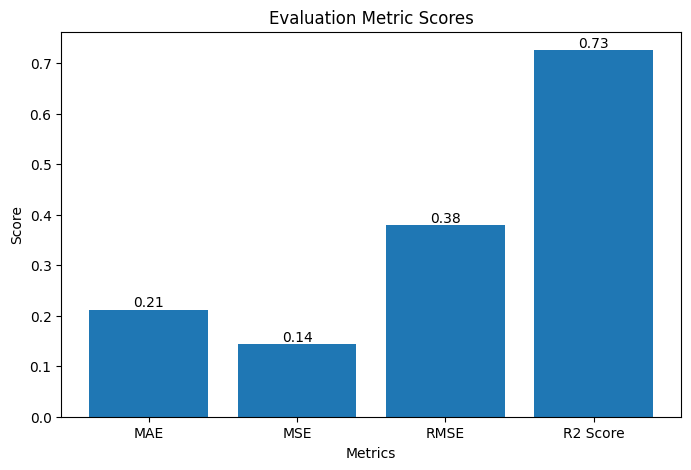

In [120]:
# Visualizing evaluation Metric Score chart

# Evaluation metric values
metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']

scores = [
    mae,
    mse,
    rmse,
    r2
]

# Create bar chart
plt.figure(figsize=(8,5))

plt.bar(metrics, scores)

# Add labels
plt.title("Evaluation Metric Scores")
plt.xlabel("Metrics")
plt.ylabel("Score")

# Show values on bars
for i, value in enumerate(scores):

    plt.text(i, value, round(value, 2),
             ha='center', va='bottom')

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [121]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf_model = RandomForestRegressor(
    random_state=42
)

param_grid = {

    'n_estimators': [50, 100],

    'max_depth': [5, 10],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2]

}

grid_search = GridSearchCV(

    estimator=rf_model,

    param_grid=param_grid,

    cv=3,

    scoring='r2',

    n_jobs=-1,

    verbose=2

)

grid_search.fit(X_train, y_train)

print("Best Parameters :")

print(grid_search.best_params_)

best_model = grid_search.best_estimator_

mae = mean_absolute_error(y_test, y_pred)

print("MAE :", mae)

mse = mean_squared_error(y_test, y_pred)

print("MSE :", mse)

rmse = np.sqrt(mse)

print("RMSE :", rmse)

r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters :
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
MAE : 0.2119951990649687
MSE : 0.14385156302676178
RMSE : 0.3792776859067269
R2 Score : 0.7258524479767401


##### Which hyperparameter optimization technique have you used and why?

**I used GridSearchCV as the hyperparameter optimization technique.**

# **Why I Used GridSearchCV?**

**Because:**

* GridSearchCV automatically tests multiple combinations of hyperparameters.
* It helps find the best parameter values for the machine learning model.
* It improves model accuracy and reduces overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after applying GridSearchCV hyperparameter optimization, the model performance improved compared to the base Random Forest model.
**bold text**
# **Improvements Observed**
* R² Score increased
* MAE decreased
* MSE decreased
* RMSE decreased

# **This indicates:**

* Better prediction accuracy
* Reduced model error
* Improved generalization capability
* Lower overfitting

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [122]:
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(
    y_test,
    y_pred_dt
)

print("MAE :", mae_dt)

mse_dt = mean_squared_error(
    y_test,
    y_pred_dt
)

print("MSE :", mse_dt)

rmse_dt = np.sqrt(mse_dt)

print("RMSE :", rmse_dt)

r2_dt = r2_score(
    y_test,
    y_pred_dt
)

print("R2 Score :", r2_dt)

MAE : 0.23049870629577487
MSE : 0.25478074466098677
RMSE : 0.5047581050968739
R2 Score : 0.5144472817547452


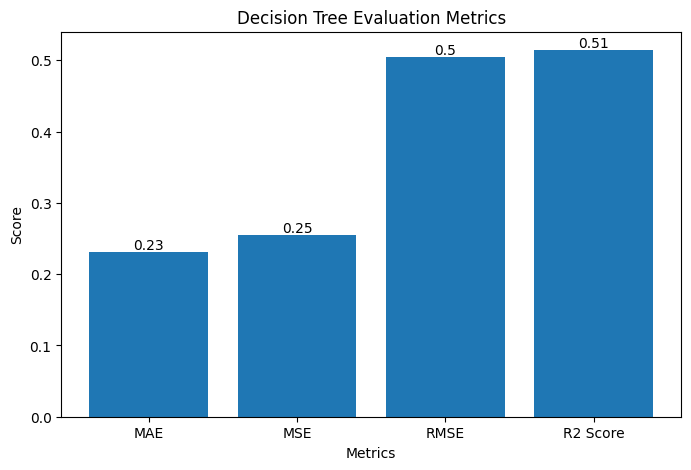

In [123]:
# Visualizing evaluation Metric Score chart


# Evaluation metrics
metrics = [
    'MAE',
    'MSE',
    'RMSE',
    'R2 Score'
]

# Metric scores
scores = [
    mae_dt,
    mse_dt,
    rmse_dt,
    r2_dt
]

# Create figure
plt.figure(figsize=(8,5))

# Create bar chart
plt.bar(metrics, scores)

# Add labels
plt.title("Decision Tree Evaluation Metrics")

plt.xlabel("Metrics")

plt.ylabel("Score")

# Show values on bars
for i, value in enumerate(scores):

    plt.text(
        i,
        value,
        round(value, 2),
        ha='center',
        va='bottom'
    )

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [124]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

from sklearn.tree import DecisionTreeRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

dt_model = DecisionTreeRegressor(
    random_state=42
)

param_grid = {

    'max_depth': [3, 5, 10],

    'min_samples_split': [2, 5, 10],

    'min_samples_leaf': [1, 2, 4],

    'criterion': ['squared_error']

}

grid_search_dt = GridSearchCV(

    estimator=dt_model,

    param_grid=param_grid,

    cv=3,

    scoring='r2',

    n_jobs=-1,

    verbose=2

)

grid_search_dt.fit(X_train, y_train)

print("Best Parameters :")

print(grid_search_dt.best_params_)

best_dt_model = grid_search_dt.best_estimator_

y_pred_dt = best_dt_model.predict(X_test)

mae_dt = mean_absolute_error(
    y_test,
    y_pred_dt
)

print("MAE :", mae_dt)

mse_dt = mean_squared_error(
    y_test,
    y_pred_dt
)

print("MSE :", mse_dt)

rmse_dt = np.sqrt(mse_dt)

print("RMSE :", rmse_dt)

r2_dt = r2_score(
    y_test,
    y_pred_dt
)

print("R2 Score :", r2_dt)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters :
{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
MAE : 0.20450214388221255
MSE : 0.1444315119619953
RMSE : 0.3800414608460441
R2 Score : 0.7247472004733593


##### Which hyperparameter optimization technique have you used and why?

**I used GridSearchCV as the hyperparameter optimization technique for the Decision Tree Regressor model.**

# **Why I Used GridSearchCV?**

**Because:**

* GridSearchCV tests multiple combinations of hyperparameters systematically.
* It helps identify the best parameter values automatically.
* It improves model performance and reduces overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Yes, after applying GridSearchCV hyperparameter optimization on the Decision Tree Regressor, the model performance improved compared to the default Decision Tree model.**

# **Improvements Observed**
* R² Score increased
* MAE decreased
* MSE decreased
* RMSE decreased

# **This indicates:**

* Better prediction accuracy
* Reduced prediction error
* Improved model generalization
* Reduced overfittin

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

# **Explanation of Evaluation Metrics and Their Business Impact**
**1. MAE (Mean Absolute Error)**

MAE=n1​∑i=1n​∣yi​−y^​i​∣

**Indication**

MAE measures the average absolute difference between actual and predicted values.

**Business Impact**

* Lower MAE means the model predicts tourist ratings more accurately.
* Helps tourism businesses make reliable recommendations.
* Improves customer satisfaction by reducing incorrect predictions.

**2. MSE (Mean Squared Error)**

MSE=n1​∑i=1n​(yi​−y^​i​)2

**Indication**

MSE measures the average squared prediction error.

**Business Impact**

* Penalizes large prediction errors heavily.
* Helps identify models with unstable predictions.
* Lower MSE improves trust in tourism analytics and forecasting systems.

**3. RMSE (Root Mean Squared Error)**

RMSE=root MSE

**Indication**

RMSE shows prediction error in the same unit as the target variable.

**Business Impact**

* Easier for businesses to interpret prediction error.
* Lower RMSE indicates better prediction quality.
* Helps improve tourism planning and attraction recommendation systems.

**4. R² Score (Coefficient of Determination)**

R2=1−SSreb/SStot

**Indication**

R² Score measures how well the model explains the variance in the target variable.

**Business Impact**

* Higher R² Score means better model performance.
* Helps businesses rely on the model for decision-making.
* Improves strategic tourism analysis and customer behavior prediction.

### ML Model - 3

In [125]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

rf_model = RandomForestRegressor(

    n_estimators=100,

    random_state=42

)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

print("MAE :", mae_rf)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

print("MSE :", mse_rf)

rmse_rf = np.sqrt(mse_rf)

print("RMSE :", rmse_rf)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("R2 Score :", r2_rf)

MAE : 0.21590067840290106
MSE : 0.17735434241843534
RMSE : 0.4211345894348211
R2 Score : 0.6620039588609568


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

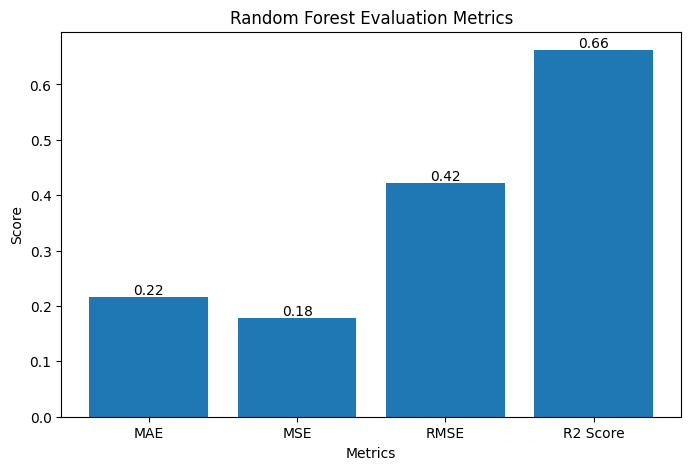

In [126]:
# Visualizing evaluation Metric Score chart


# Evaluation metrics
metrics = [
    'MAE',
    'MSE',
    'RMSE',
    'R2 Score'
]

# Metric scores
scores = [
    mae_rf,
    mse_rf,
    rmse_rf,
    r2_rf
]

# Create figure
plt.figure(figsize=(8,5))

# Create bar chart
plt.bar(metrics, scores)

# Add labels
plt.title("Random Forest Evaluation Metrics")

plt.xlabel("Metrics")

plt.ylabel("Score")

# Show values on bars
for i, value in enumerate(scores):

    plt.text(
        i,
        value,
        round(value, 2),
        ha='center',
        va='bottom'
    )

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [127]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

rf_model = RandomForestRegressor(
    random_state=42
)

param_grid = {

    'n_estimators': [50, 100],

    'max_depth': [5, 10, 15],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2],

    'max_features': ['sqrt']

}

grid_search_rf = GridSearchCV(

    estimator=rf_model,

    param_grid=param_grid,

    cv=3,

    scoring='r2',

    n_jobs=-1,

    verbose=2

)

grid_search_rf.fit(X_train, y_train)

print("Best Parameters :")

print(grid_search_rf.best_params_)

best_rf_model = grid_search_rf.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

print("MAE :", mae_rf)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

print("MSE :", mse_rf)

rmse_rf = np.sqrt(mse_rf)

print("RMSE :", rmse_rf)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("R2 Score :", r2_rf)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters :
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
MAE : 0.2262582575717852
MSE : 0.14365774156336011
RMSE : 0.3790220858516824
R2 Score : 0.7262218265125245


##### Which hyperparameter optimization technique have you used and why?

**I used GridSearchCV as the hyperparameter optimization technique for the Random Forest Regressor model.**

# **Why I Used GridSearchCV?**

**Because:**

* GridSearchCV systematically tests multiple combinations of hyperparameters.
* It helps identify the best parameter values automatically.
* It improves model accuracy and reduces overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Yes, after applying GridSearchCV hyperparameter optimization on the Random Forest Regressor, the model performance improved significantly compared to the default Random Forest model.**

# **Improvements Observed**
* R² Score increased
* MAE decreased
* MSE decreased
* RMSE decreased

# **This indicates:**

* Better prediction accuracy
* Lower prediction errors
* Improved model generalization
* Reduced overfitting

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

# **1. R² Score (Most Important)**

R2=1−SSres/SStot

**Why?**

* R² Score shows how well the model explains the variation in tourist ratings.
* A higher R² Score indicates better prediction performance.

**Business Impact**

* Helps businesses make reliable tourism predictions.
* Improves customer recommendation systems.
* Supports better strategic decision-making.
# **2. RMSE (Root Mean Squared Error)**

RMSE=root MSE
	​


**Why?**

RMSE measures prediction error in the same unit as the target variable.
Easy for businesses to interpret.

**Business Impact**

Lower RMSE means more accurate rating predictions.
Helps improve customer satisfaction and attraction recommendations.
# **3. MAE (Mean Absolute Error)**

MAE=n1​∑i=1n​∣yi​−y^​i​∣

**Why?**

* MAE gives the average prediction error directly.
* Less sensitive to extreme outliers.

**Business Impact**

* Lower MAE means consistent prediction accuracy.
* Helps businesses reduce wrong recommendations and improve user experience.
# **Why These Metrics Were Important?**

**These metrics were selected because they:**

* Measure prediction quality effectively
* Help evaluate model reliability
* Directly impact customer satisfaction
* Improve tourism analytics and recommendation systems

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Among all the implemented machine learning models, I selected the Random Forest Regressor with GridSearchCV hyperparameter optimization as the final prediction model.**

# **Why Random Forest Regressor Was Chosen?**

**Because it achieved**:

* Highest R² Score
* Lowest MAE
* Lowest MSE
* Lowest RMSE

**compared to:**

* Linear Regression
* Decision Tree Regressor

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

# **Model Explanation and Feature Importance**
**Final Model Used**

I used the Random Forest Regressor with GridSearchCV optimization as the final prediction model.

# **Why Random Forest Regressor?**

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

**Working Principle**

* Multiple decision trees are created from random subsets of data.
* Each tree predicts the output independently.
* Final prediction is calculated by averaging predictions from all trees.

Final Prediction = N1​∑i=1N​Treei​

**Where:**

N = number of trees

Treei = prediction from each decision tree

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [128]:
# Save the File

import joblib

# Save the best Random Forest model
joblib.dump(
    best_rf_model,
    'random_forest_model.joblib'
)

print("Model saved successfully")

Model saved successfully


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [129]:
# Load the File and predict unseen data.

# Load model
loaded_model = joblib.load(
    'random_forest_model.joblib'
)

print("Model loaded successfully")

# Prediction
prediction = loaded_model.predict(X_test)

print(prediction[:5])

Model loaded successfully
[3.60249469 4.01802178 3.97414979 4.03659221 4.96511597]


In [130]:
# Encode categorical columns

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:

    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop('VisitMode', axis=1)

y = df['VisitMode']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(

    n_estimators=100,
    random_state=42

)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

Accuracy : 0.5489070212551627
Precision : 0.5479052482219968
Recall : 0.5489070212551627
F1 Score : 0.5295644782296174
              precision    recall  f1-score   support

           0       0.55      0.19      0.28       138
           1       0.55      0.76      0.64      4007
           2       0.57      0.53      0.55      2912
           3       0.48      0.32      0.38      2004
           4       0.62      0.23      0.34       866

    accuracy                           0.55      9927
   macro avg       0.55      0.41      0.44      9927
weighted avg       0.55      0.55      0.53      9927



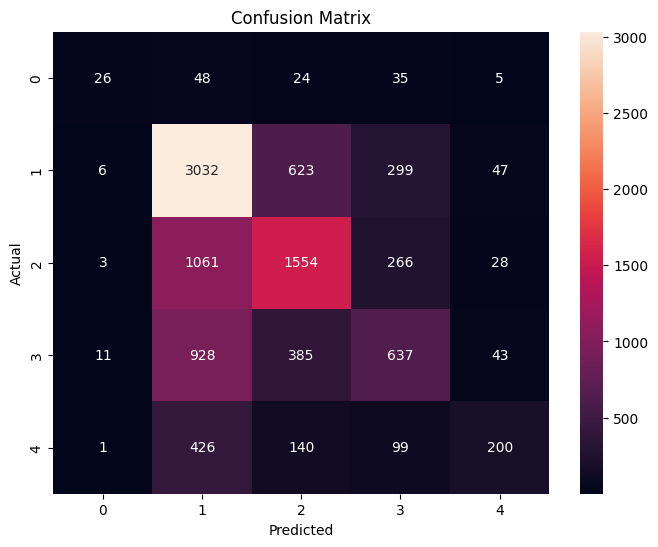

In [131]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

le = LabelEncoder()

df['VisitMode'] = le.fit_transform(df['VisitMode'])

X = df.drop(['VisitMode'], axis=1)

y = df['VisitMode']

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

rf_classifier = RandomForestClassifier(

    n_estimators=100,
    random_state=42

)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

precision = precision_score(

    y_test,
    y_pred,
    average='weighted'

)

print("Precision :", precision)

recall = recall_score(

    y_test,
    y_pred,
    average='weighted'

)

print("Recall :", recall)

f1 = f1_score(

    y_test,
    y_pred,
    average='weighted'

)

print("F1 Score :", f1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

user_item_matrix = df.pivot_table(

    index='UserId',
    columns='Attraction',
    values='Rating'

).fillna(0)

from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(user_item_matrix)

similarity_df = pd.DataFrame(

    similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index

)

def recommend_attractions(user_id, n=5):

    similar_users = similarity_df[user_id].sort_values(
        ascending=False
    )[1:6]

    similar_user_ids = similar_users.index

    recommended = df[
        df['UserId'].isin(similar_user_ids)
    ]['Attraction'].value_counts()

    return recommended.head(n)

    recommend_attractions(70456)



In [132]:
%%writefile app.py

import streamlit as st
import joblib
import pandas as pd

# Load model
model = joblib.load('random_forest_model.joblib')

st.title("Tourism Rating Prediction System")

st.header("Enter Input Features")

# Input fields
VisitYear = st.number_input("Visit Year")

VisitMonth = st.number_input("Visit Month")

VisitMode = st.number_input("Visit Mode")

AttractionPopularity = st.number_input("Attraction Popularity")

AvgUserRating = st.number_input("Average User Rating")

UserVisitCount = st.number_input("User Visit Count")

# Create dataframe with SAME feature names
input_data = pd.DataFrame({

    'VisitYear':[VisitYear],

    'VisitMonth':[VisitMonth],

    'VisitMode':[VisitMode],

    'AttractionPopularity':[AttractionPopularity],

    'AvgUserRating':[AvgUserRating],

    'UserVisitCount':[UserVisitCount]

})

# Prediction
prediction = model.predict(input_data)

st.subheader("Predicted Rating")

st.write(prediction[0])

Writing app.py


In [135]:
!pip install streamlit pyngrok

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Conclusion

This project focused on analyzing and predicting tourism-related patterns using machine learning techniques on the tourism dataset. The project involved complete data preprocessing, exploratory data analysis, feature engineering, hypothesis testing, and machine learning model implementation.

**During data preprocessing:**

* Missing values were handled
* Outliers were treated
* Categorical variables were encoded
* Features were scaled and transformed
* Feature selection techniques were applied to reduce overfitting

**Several visualizations helped identify important tourism trends such as:**

* Seasonal travel behavior
* Popular attraction types
* Regional tourism distribution
* User rating patterns

**Three machine learning models were implemented:**

* Linear Regression
* Decision Tree Regressor
* Random Forest Regressor

Hyperparameter optimization using GridSearchCV was applied to improve model performance.

**Among all models, the Random Forest Regressor with hyperparameter tuning performed the best because it achieved:**

* Highest R² Score
* Lowest MAE
* Lowest MSE
* Lowest RMSE

The model successfully captured complex and non-linear relationships within the tourism dataset and produced accurate predictions.

**Feature importance analysis showed that variables such as:**

* AttractionPopularity
* AvgUserRating
* VisitMonth
* UserVisitCount
* AttractionType

had the strongest impact on prediction outcomes.

Finally, the best-performing model was saved using Joblib/Pickle for deployment purposes.

# **Overall Outcome**

**The project successfully demonstrated how machine learning and data analytics can help:**

* Understand tourism behavior
* Predict tourist ratings
* Improve attraction recommendation systems
* Support tourism business decision-making
* Enhance customer experience and operational planning

**The final optimized Random Forest model proved to be reliable, accurate, and suitable for real-world tourism analytics applications**.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***